# Graphs with Matplotlib

Graphical representation is one of the most powerful tools for exploring and visualizing functions and data, and nowadays one of the most important tasks for both engineers and scientists. In fact, graphs are used both to present data and to understand it, as well as to visually check computed results.

The most widely used Python module for graphical representation is **Matplotlib** (<http://matplotlib.org/>), which will be the main one we use in this course. This module is very powerful and has a huge number of features. In this section we will limit ourselves to its use for graphing functions of one variable. To get an idea of all the possibilities offered by this module, you may visit the *Matplotlib Gallery* (https://matplotlib.org/stable/gallery/index.html).


## Using Matplotlib

To use **Matplotlib**, we need to import its module. Since we will use it through the `pyplot` interface, it is also necessary to import it:


In [1]:
import matplotlib as mp
import matplotlib.pyplot as plt
mp.__version__

'3.10.0'

Of course, in order to perform numerical calculations efficiently, we also need to import the **NumPy** module:


In [2]:
import numpy as np

**Matplotlib** is a Python library that can be used outside Jupyter *Notebooks* to graph both functions and geometric entities (either on screen or to save them to a file). In order for the graphs to appear embedded in this document, we will use the *magic* command `%matplotlib inline`.
On the other hand, if it is necessary to interact with the graphs, we should use the `%matplotlib notebook` option.


In [3]:
%matplotlib inline

## Graphs of one-variable functions

The graphs of one-variable functions are created from the evaluation of the function values at a large number of points stored in a **NumPy** array. When enough points are used, a cinematic effect is created, and the graph of the function appears smooth. However, one must understand that what is being graphed is a concatenation of straight segments joining the evaluated points. For example, to represent the functions

$$
f(x) = \sin(x),\qquad g(x)=\cos(x),\qquad x\in[0,4\pi].
$$

the first step is to create an array of values at which the function will be evaluated. For that, the `np.linspace` function is used as follows:


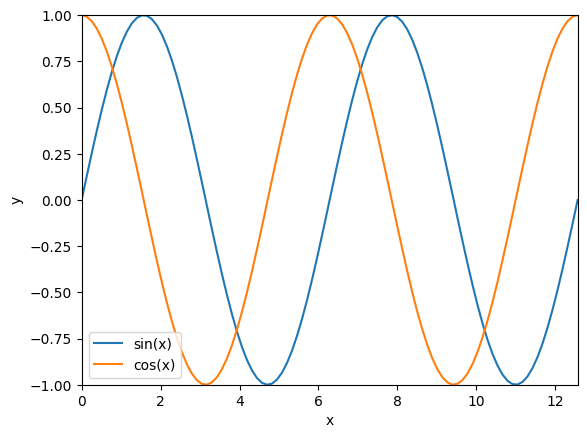

In [4]:
# Create the points where the function is evaluated
x = np.linspace(0, 4*np.pi, 100)

# Plot sin(x) and cos(x), with a label for each one
plt.plot(x, np.sin(x), label='sin(x)')
plt.plot(x, np.cos(x), label='cos(x)')

# Axis labels
plt.xlabel('x')
plt.ylabel('y')

# Add the legend (showing the labels from the plots)
plt.legend()

# Set the x- and y-axis limits
plt.xlim(x[0], x[-1])
plt.ylim([-1.,1.])

plt.show()

For graphing function plots with **Matplotlib** there are many options, which you can see here:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

For example:


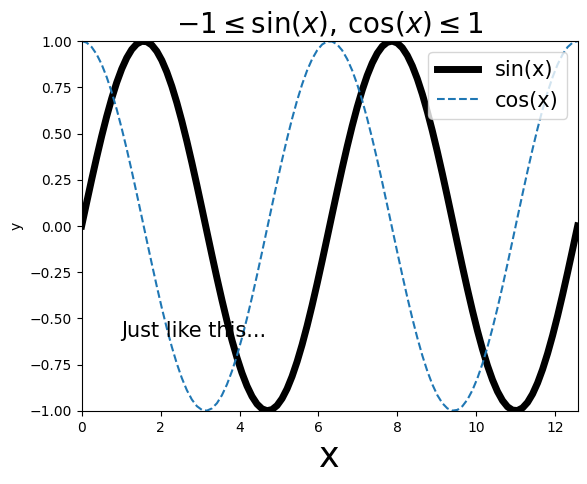

In [5]:
# Create the points at which the function is evaluated
x = np.linspace(0, 4*np.pi, 100)

# Plot sin(x) and cos(x), with a label for each one
# Draw the sine curve thicker and in black. The cosine curve uses a dashed line
plt.plot(x, np.sin(x), label='sin(x)', lw='5', c='black')
plt.plot(x, np.cos(x), label='cos(x)', ls='--')

# Axis labels (the "X" with a larger font)
plt.xlabel('x', fontsize=25)
plt.ylabel('y')

# Add explanatory text wherever it seems best
plt.title(r'$-1\leq\sin(x), \, \cos(x)\leq 1$', fontsize=20)
plt.text(1, -0.6, r'Just like this...', fontsize=15)

# Add the label for each function
# Place it in the upper-right corner
plt.legend(loc='upper right',fontsize=15)

# Set the x- and y-axis limits
plt.xlim(x[0], x[-1])
plt.ylim([-1.,1.])

plt.show()

If we want a graph with several subplots:


<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7618/3560949147.py:26: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('Range between $-\pi/2$ and $\pi/2$', fontsize=15)
/tmp/ipykernel_7618/3560949147.py:31: SyntaxWarning: invalid escape sequence '\p'
  ax4.set_ylabel('Range between $-\pi/2$ and $\pi/2$', fontsize=15)


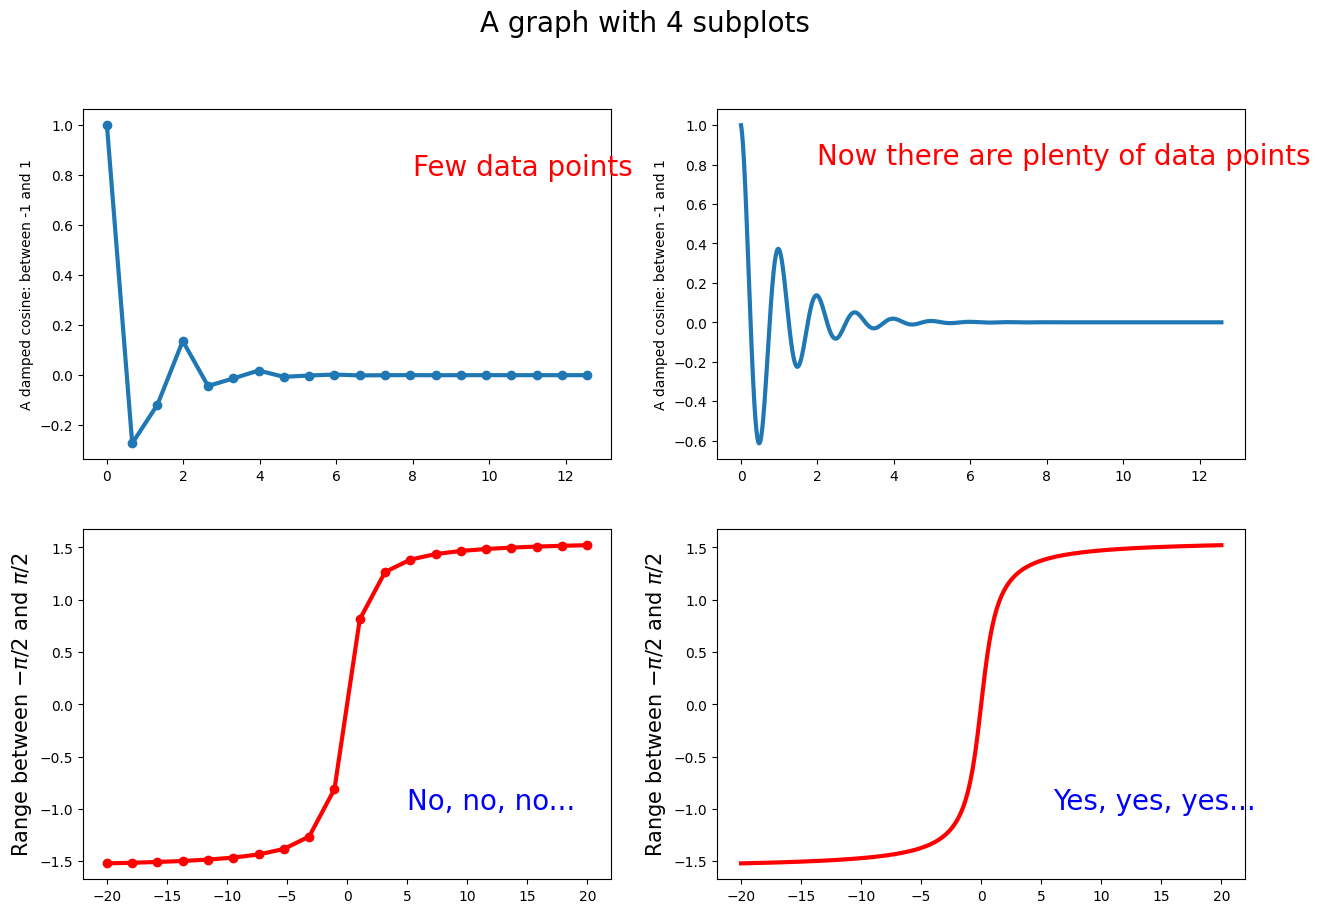

In [6]:

# Create function plots
x1 = np.linspace(0.0, 4*np.pi, 20)
y1 = np.cos(2 * np.pi * x1) * np.exp(-x1)
x2 = np.linspace(0.0, 4*np.pi, 1000)
y2 = np.cos(2 * np.pi * x2) * np.exp(-x2)
x3 = np.linspace(-20.0, 20.0, 20)
y3 = np.arctan(x3)
x4 = np.linspace(-20.0, 20.0, 200)
y4 = np.arctan(x4)

fig, axs = plt.subplots(2, 2, figsize=(15,10))
fig.suptitle('A graph with 4 subplots', fontsize=20)

ax1 = axs[0,0]
ax1.plot(x1, y1, 'o-', lw='3')
ax1.set_ylabel('A damped cosine: between -1 and 1', fontsize=10)
ax1.text(8, 0.8, 'Few data points', c='r', fontsize=20)

ax2 = axs[0,1]
ax2.plot(x2, y2, '-', lw='3')
ax2.set_ylabel('A damped cosine: between -1 and 1', fontsize=10)
ax2.text(2, 0.8, 'Now there are plenty of data points', c='r', fontsize=20)

ax3 = axs[1,0]
ax3.plot(x3, y3, 'o-', c='r', lw='3')
ax3.set_ylabel('Range between $-\pi/2$ and $\pi/2$', fontsize=15)
ax3.text(5, -1, 'No, no, no...', c='b', fontsize=20)

ax4 = axs[1,1]
ax4.plot(x4, y4, c='r',  lw='3')
ax4.set_ylabel('Range between $-\pi/2$ and $\pi/2$', fontsize=15)
ax4.text(6, -1, 'Yes, yes, yes...', c='b', fontsize=20)

plt.show()

## Use of **sp.lambdify**

In the rest of this tutorial, as well as in the rest of the course, we will need a symbolic function from **Sympy** to act on variables storing floating-point numbers or **NumPy** arrays. In particular, although the utilities of this command are much broader, we will need it to graph the functions obtained in **Matplotlib**.

This is achieved by using the `sp.lambdify` function.

Below we show its use through an example. In it we denote by *f* the Sympy function and by *fn* the numerical function generated from it with `sp.lambdify`.


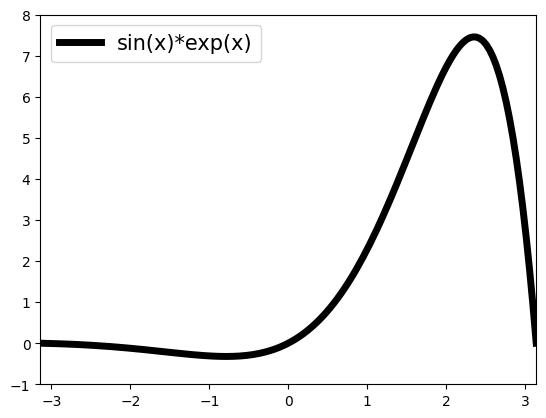

In [8]:
import sympy as sp
import numpy as np
x=sp.symbols('x')
# The function f is symbolic: we cannot evaluate it
# at numerical variables storing floating-point values,
# or at NumPy arrays
f_exp = sp.sin(x)*sp.exp(x)
# The function fn is numerical, and we can evaluate it at floating-point numbers or NumPy arrays
fn = sp.lambdify(x,f_exp)

# Now, to graph it with Matplotlib, we evaluate it on an array of points
x=np.linspace(-np.pi,np.pi,150)
# print(fn(x))

plt.plot(x, fn(x), label='sin(x)*exp(x)', lw='5', c='black')
plt.legend(loc='upper left',fontsize=15)
# Set the x- and y-axis limits
plt.xlim(x[0], x[-1])
plt.ylim([-1.,8.])
plt.show()

We will leave it to you to play around a little with `Matplotlib`...
